## Thematic Network of Key Concepts: Heat Exposure Among Migrant Workers

In [2]:
install.packages(c("igraph","tidyverse", "ggraph"))


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘tweenr’, ‘polyclip’, ‘gridExtra’, ‘RcppArmadillo’, ‘ggforce’, ‘ggrepel’, ‘viridis’, ‘tidygraph’, ‘graphlayouts’




In [3]:
# Load packages
library(igraph)
library(tidyverse)
library(ggraph)
library(tidygraph)
library(ggplot2)
library(viridis)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%--%()      masks igraph::%--%()
✖ dplyr::as_data_frame() masks tibble::as_data_frame(), igraph::as_data_frame()
✖ purrr::compose()       masks igraph::compose()
✖ tidyr::crossing()      masks igraph::crossing()
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ purrr::simplify()      masks igraph::simplify()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachin

### Prepare data

In [4]:
keywords_raw <- tibble(
  study_id = c(1, 17, 36:53),
  year = c(
    2025, 2023, 2024, 2014, 2019, 2022, 2020, 2014,
    2024, 2021, 2022, 2019, 2020, 2022, 2020, 2019,
    2015, 2020, 2020, 2019
  ),
  keywords = c(
    "International migrants; Occupational Health; Migrant workers; Heat exposure; Climate change",
    "Heat strain; Heat stress; Migrants; Workers",
    "Dehydration; Farmworkers; Heat exposure; Urine specific gravity",
    "climate; weather; laborers; outdoor jobs; Bahrain",
    "agricultural work; contingent workers; diversity; health surveillance; immigrant; occupational health and safety programs; research; safety; workforce",
    "COVID-19; Latina; US–Mexico; farmworkers; mental health; occupational stress; stress",
    "Latino/Hispanic; agricultural health; child labor; health disparities; health equity; heat-related illness; migrant and seasonal farmworkers; occupational health",
    "Adult; Agriculture; Cross-Sectional Studies; Early Detection of Cancer; Eye Protective Devices; Health Behavior; Health Knowledge, Attitudes, Practice; Hispanic or Latino / psychology; Humans; Interviews as Topic; Male; Mexico / ethnology; Middle Aged; North Carolina; Occupational Diseases / diagnosis; Occupational Diseases / prevention & control; Occupational Health; Protective Clothing; Skin Neoplasms / diagnosis; Skin Neoplasms / prevention & control; Sunscreening Agents / therapeutic use; Transients and Migrants / psychology; Ultraviolet Rays / adverse effect",
    "chronic kidney failure; chronic renal insufficiency; end stage renal disease; hemodialysis; Nepal",
    "agricultural workers; disease prevention; first aid; heat-illness; migrant health; rural health",
    "occupational histories; topic modeling; emergent dialysis; undocumented workers",
    "Latino immigrants; Work organization; forest workers; institutional racism; occupational safety and health; safety climate",
    "Adolescent; Adult; Aged; Aged 80 and over; Checklist / standards; Cross-Sectional Studies; Dominican Republic / epidemiology; Emigrants and Immigrants / psychology; Female; Foot Diseases / diagnosis; Foot Diseases / epidemiology; Foot Injuries / diagnosis; Foot Injuries / epidemiology; Haiti / ethnology; Humans; Male; Middle Aged; Quality of Life; Rural Population; Vulnerable Populations; Young Adult",
    "farmworkers; fluid intake; heat-related illness; hydration status",
    "Cooling practices; farmworker; heat-related illness; hydration; Hispanic",
    "Cooling practices; farmworker; heat-related illness; hydration; Hispanic",
    "Central America; agricultural worker; chronic kidney disease; climate change; heat stress; sugarcane",
    "Adult; Dehydration / diagnosis; Emergency Service, Hospital; Farmers; Heat Exhaustion / diagnosis; Human Trafficking; Humans; Male; Mississippi; Occupational Exposure; Pesticides; Renal Insufficiency / diagnosis; Transients and Migrants",
    "infertility; risk factors; semen abnormality parameters",
    "Adult; Cultural Competency; Depression; Farmers; Female; Humans; Mexico / ethnology; Pregnancy; Pregnancy Complications / prevention & control; Prenatal Care / organization & administration; Psychological Distance; Sociology, Medical; Transients and Migrants"
  )
)



### Convert Keywords into Long Format

In [5]:
keywords_long <- keywords_raw %>%
  mutate(keywords = str_split(keywords, ";")) %>%
  unnest(keywords) %>%
  mutate(keyword = str_trim(keywords)) %>%
  select(study_id, year, keyword)


tail(keywords_long, 10)


study_id,year,keyword
<dbl>,<dbl>,<chr>
53,2019,Farmers
53,2019,Female
53,2019,Humans
53,2019,Mexico / ethnology
53,2019,Pregnancy
53,2019,Pregnancy Complications / prevention & control
53,2019,Prenatal Care / organization & administration
53,2019,Psychological Distance
53,2019,"Sociology, Medical"


#### Split Keywords further and convert to lower

In [6]:
library(purrr)

keywords_separated <- keywords_long %>%
  mutate(
    keyword = map_chr(
      keyword,
      ~ .x %>%
        str_split("\\s*/\\s*|,\\s*") %>%  # split on / or ,
        unlist() %>%
        str_trim() %>%
        str_to_lower() %>%
        paste(collapse = " ")
    )
  )

tail(keywords_separated,10)

study_id,year,keyword
<dbl>,<dbl>,<chr>
53,2019,farmers
53,2019,female
53,2019,humans
53,2019,mexico ethnology
53,2019,pregnancy
53,2019,pregnancy complications prevention & control
53,2019,prenatal care organization & administration
53,2019,psychological distance
53,2019,sociology medical


### Regularization



In [7]:
keyword_dictionary <- tribble(
  ~pattern, ~standardized,

  # Heat exposure & physiology
  "heat strain|heat stress|heat exposure|heat-related illness|heat-illness|heat exhaustion diagnosis",
  "heat stress & illness",

  # Hydration
  "dehydration|dehydration diagnosis|hydration|hydration status|fluid intake",
  "dehydration & hydration",

  # Kidney disease
  "chronic kidney failure|urine specific gravity|chronic renal insufficiency|end stage renal disease|renal insufficiency diagnosis|chronic kidney disease|hemodialysis|emergent dialysis",
  "chronic kidney conditions",

  # Skin disease
  "skin neoplasms diagnosis|skin neoplasms prevention & control",
  "skin disease",

  # Foot disease
  "foot diseases diagnosis|foot diseases epidemiology|foot injuries diagnosis|foot injuries epidemiology",
  "foot conditions",

  # Migrant & worker populations
  "international migrants|migrants|immigrant|emigrants and immigrants psychology|transients and migrants|transients and migrants psychology|migrant workers|undocumented workers|migrant and seasonal farmworkers",
  "migrants",
  "farmworker|farmworkers|agricultural worker|agricultural workers|farmers|agricultural work|sugarcane",
  "agricultural workers",
  "laborers|workers|workforce|contingent workers|forest workers",
  "other workers",

  # Occupational context
  "occupational health and safety programs|occupational safety and health|occupational health|occupational diseases diagnosis|occupational diseases prevention & control|occupational health|occupational exposure|occupational stress|occupational histories|outdoor jobs|pesticides|risk factors",
  "occupational health & exposure",

  # Climate & environment
  "climate|climate change|weather|ultraviolet rays adverse effect",
  "climate",

  # Mental & social health
  "mental health|depression|stress|psychological distance",
  "mental health",
  "health disparities|health equity|health knowledge attitudes practice|agricultural health|health behavior|migrant health|rural health|emergency service hospital",
  "health status",
  "cultural competency|institutional racism|quality of life|work organization|human trafficking|diversity|sociology medical",
  "social health",

  # Prevention & behavior
  "cooling practices|safety|protective clothing|sunscreening agents therapeutic use|first aid|early detection of cancer|eye protective devices|disease prevention|health surveillance",
  "preventive practices",

  # Ethnicity
  "latina|latino immigrants|latino|latino hispanic|hispanic|hispanic or latino|hispanic or latino psychology|mexico ethnology",
  "hispanic",

  # Age
  "adult|aged|aged 80 and over|middle aged|adolescent|young adult|child labor",
  "age group",

  # Gender
  "male|female",
  "gender",

  # Geography
  "north carolina|mississippi|nepal|bahrain|haiti ethnology|dominican republic epidemiology|us–mexico|central america",
  "geographic context",

  # Population
  "rural population|vulnerable populations|humans",
  "population",

  # Fertility
  "pregnancy|pregnancy complications prevention & control|prenatal care organization & administration|infertility|semen abnormality parameters",
  "fertility issues",

  # Research
  "research|topic modeling|cross-sectional studies|interviews as topic",
  "research",

)

In [8]:
keywords_regularized <- keywords_separated %>%
  mutate(
    keyword_std = map_chr(keyword, function(k) {
      match <- keyword_dictionary %>%
        filter(str_detect(k, pattern))

      if (nrow(match) > 0) {
        match$standardized[1]
      } else {
        k
      }
    })
  )

head(keywords_regularized)

study_id,year,keyword,keyword_std
<dbl>,<dbl>,<chr>,<chr>
1,2025,international migrants,migrants
1,2025,occupational health,occupational health & exposure
1,2025,migrant workers,migrants
1,2025,heat exposure,heat stress & illness
1,2025,climate change,climate
17,2023,heat strain,heat stress & illness


Define “older” vs “newer” studies: use median year

In [9]:
median_year <- median(keywords_regularized$year)

keywords_regularized <- keywords_regularized %>%
  mutate(
    period = if_else(year <= median_year, "Older studies", "Newer studies")
  )


In [10]:
median_year

[1] 2020

Build co-occurrence networks by period

In [11]:
build_edges <- function(df) {
  df %>%
    distinct(study_id, keyword_std) %>%
    inner_join(., ., by = "study_id", relationship = "many-to-many") %>%
    filter(keyword_std.x < keyword_std.y) %>%
    count(keyword_std.x, keyword_std.y, name = "weight") %>%
    rename(from = keyword_std.x, to = keyword_std.y)
}


Older studies network

In [12]:
edges_old <- keywords_regularized %>%
  filter(period == "Older studies") %>%
  build_edges()

g_old <- graph_from_data_frame(edges_old, directed = FALSE)


Newer studies network

In [13]:
edges_new <- keywords_regularized %>%
  filter(period == "Newer studies") %>%
  build_edges()

g_new <- graph_from_data_frame(edges_new, directed = FALSE)


Visualize older vs new

In [14]:
install.packages('patchwork')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [15]:
V(g_old)$community <- as.factor(cluster_louvain(g_old)$membership)
V(g_new)$community <- as.factor(cluster_louvain(g_new)$membership)


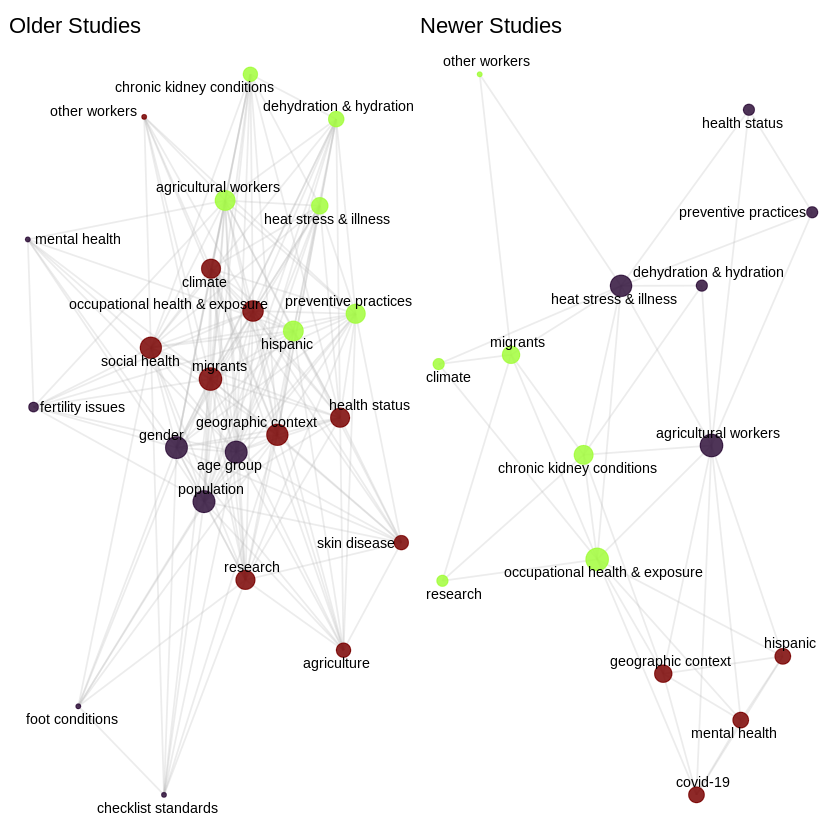

In [16]:
library(patchwork)

p_old <- ggraph(g_old, layout = "fr") +
  geom_edge_link(alpha = 0.25, colour = "grey70") +
  geom_node_point(aes(size = centrality_degree(), color = community), alpha = 0.85) +
  geom_node_text(aes(label = name), repel = TRUE, size = 3) +
  scale_color_viridis_d(option = "turbo") +
  theme_void() +
  theme(legend.position = "none") +
  labs(title = "Older Studies")

p_new <- ggraph(g_new, layout = "fr") +
  geom_edge_link(alpha = 0.25, colour = "grey70") +
  geom_node_point(aes(size = centrality_degree(), color = community), alpha = 0.85) +
  geom_node_text(aes(label = name), repel = TRUE, size = 3) +
  scale_color_viridis_d(option = "turbo") +
  theme_void() +
  theme(legend.position = "none") +
  labs(title = "Newer Studies")

p_old + p_new


Older studies exhibit a dense network, with many tightly connected health, occupation, and population terms.

Newer studies are more thematically focused with clearer separation between climate, migration, occupational exposure, and specific health outcomes.

Separate different communities in different periods

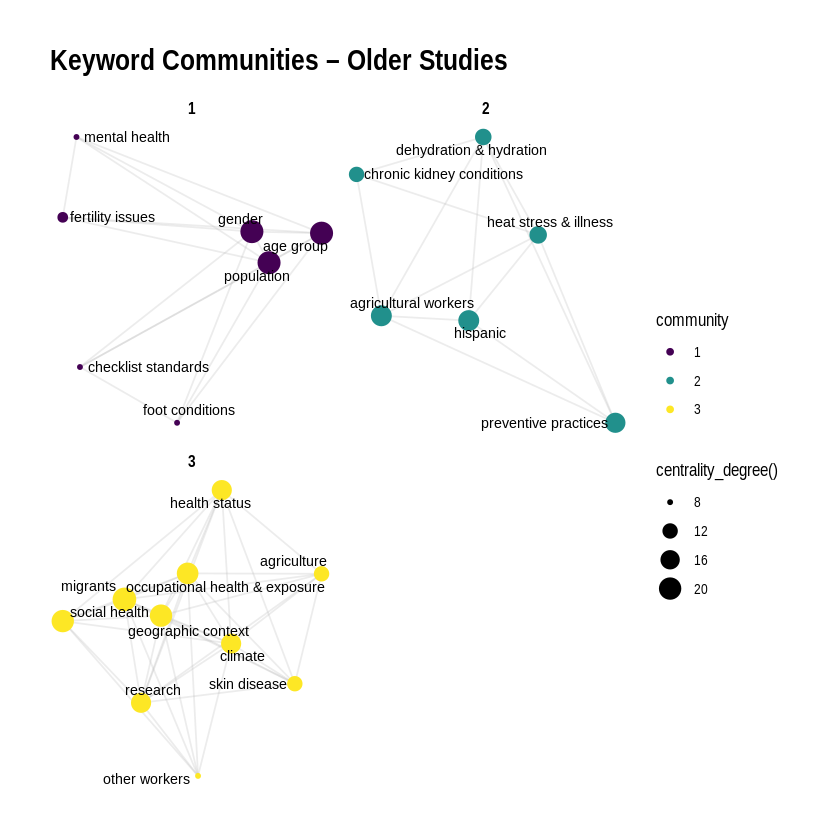

In [17]:
ggraph(g_old, layout = "fr") +
  geom_edge_link(alpha = 0.25, colour = "grey70") +
  geom_node_point(aes(color = community, size = centrality_degree())) +
  geom_node_text(aes(label = name), repel = TRUE, size = 3) +
  # separate clusters
  facet_nodes(~community, scales = "free", ncol = 2) +
  scale_color_viridis_d() +
  theme_graph() +
  labs(title = "Keyword Communities – Older Studies")


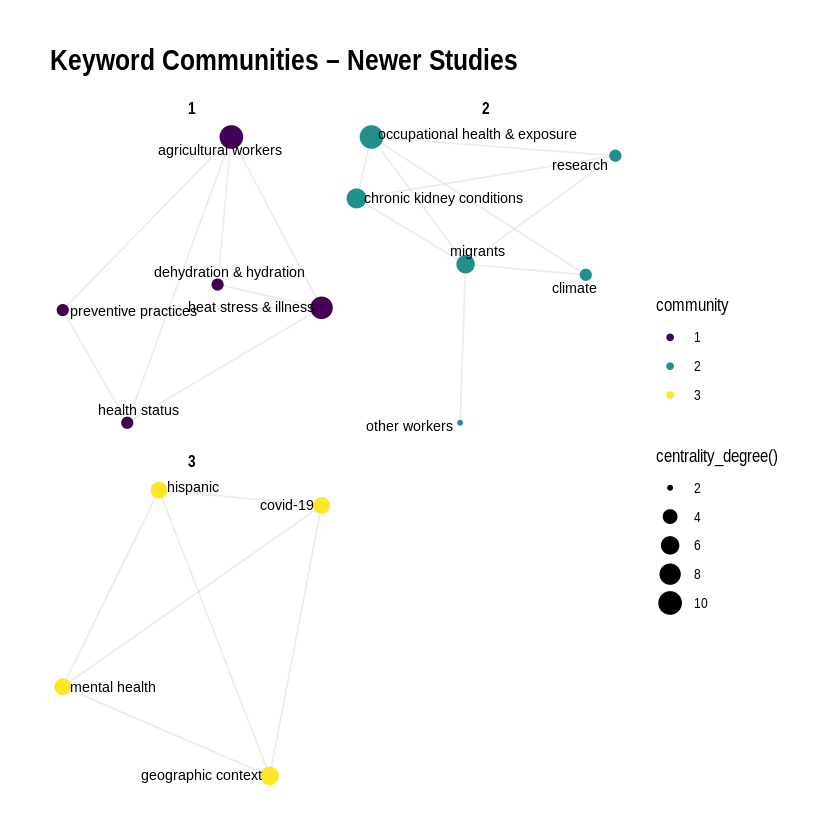

In [18]:
ggraph(g_new, layout = "fr") +
  geom_edge_link(alpha = 0.25, colour = "grey70") +
  geom_node_point(aes(color = community, size = centrality_degree())) +
  geom_node_text(aes(label = name), repel = TRUE, size = 3) +
  # separate clusters
  facet_nodes(~community, scales = "free", ncol = 2) +
  scale_color_viridis_d() +
  theme_graph() +
  labs(title = "Keyword Communities – Newer Studies")


Extract keyword–community table


In [19]:
old_membership <- tibble(
  keyword = V(g_old)$name,
  community_old = V(g_old)$community
)

new_membership <- tibble(
  keyword = V(g_new)$name,
  community_new = V(g_new)$community
)

In [20]:
# Identify keywords present in both periods

community_changes <- old_membership %>%
  inner_join(new_membership, by = "keyword")
community_changes

keyword,community_old,community_new
<chr>,<fct>,<fct>
agricultural workers,2,1
chronic kidney conditions,2,2
climate,3,2
dehydration & hydration,2,1
geographic context,3,3
health status,3,1
heat stress & illness,2,1
hispanic,2,3
mental health,1,3


In [21]:
# Flag keywords that changed community
keywords_changed <- community_changes %>%
  filter(community_old != community_new) %>%
  arrange(keyword)

keywords_changed

keyword,community_old,community_new
<chr>,<fct>,<fct>
agricultural workers,2,1
climate,3,2
dehydration & hydration,2,1
health status,3,1
heat stress & illness,2,1
hispanic,2,3
mental health,1,3
migrants,3,2
occupational health & exposure,3,2


In [22]:
# Identify keywords that dropped out of the research landscape
faded_keywords <- old_membership %>%
  anti_join(new_membership, by = "keyword")

# View the keywords that are no longer central
faded_keywords

keyword,community_old
<chr>,<fct>
age group,1
agriculture,3
checklist standards,1
fertility issues,1
foot conditions,1
gender,1
population,1
skin disease,3
social health,3


Network level metrics

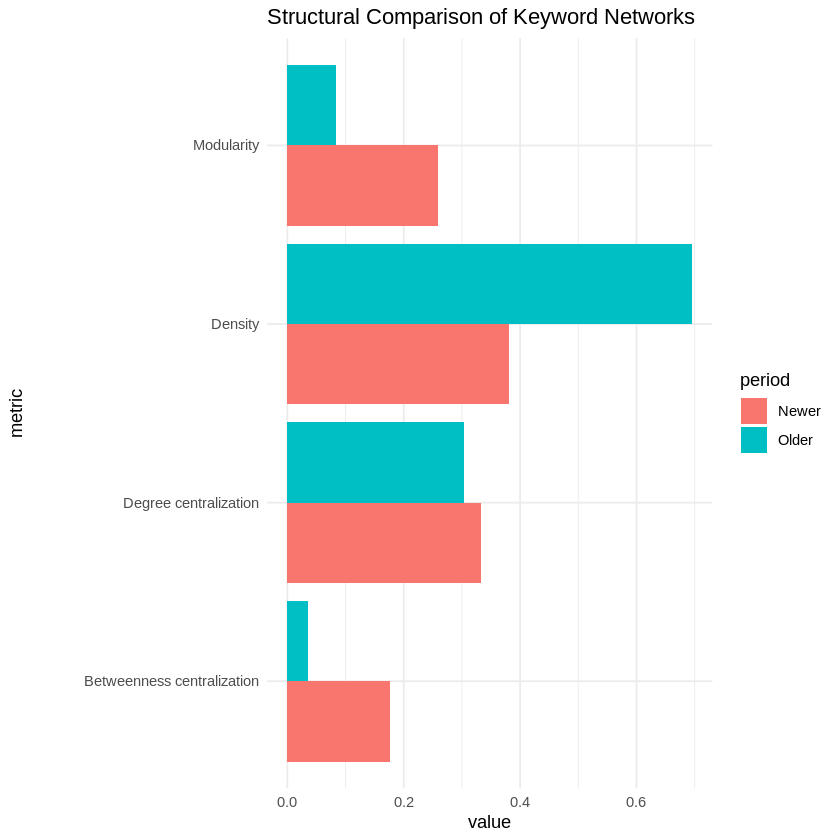

In [23]:
ggplot(
  tibble(
    period = rep(c("Older", "Newer"), each = 4),
    metric = rep(c("Density", "Modularity",
                   "Degree centralization",
                   "Betweenness centralization"), 2),
    value = c(
      edge_density(g_old),
      modularity(cluster_louvain(g_old)),
      centr_degree(g_old, normalized = TRUE)$centralization,
      centr_betw(g_old, normalized = TRUE)$centralization,
      edge_density(g_new),
      modularity(cluster_louvain(g_new)),
      centr_degree(g_new, normalized = TRUE)$centralization,
      centr_betw(g_new, normalized = TRUE)$centralization
    )
  ),
  aes(metric, value, fill = period)
) +
  geom_col(position = "dodge") +
  coord_flip() +
  theme_minimal() +
  labs(title = "Structural Comparison of Keyword Networks")


Compared to earlier studies, newer research on heat exposure among migrant workers exhibits lower network density but higher modularity and centralization. This indicates a transition from broad, exploratory scholarship toward a more structured and conceptually focused field. Newer studies are organized around well-defined thematic clusters anchored by central keywords, with a small number of bridging concepts facilitating interdisciplinary integration. These structural changes reflect the maturation of the literature and highlight opportunities for future research that more explicitly connects health outcomes, prevention strategies, and climate-related occupational risks.